In [52]:
import numpy as np

def setup_parameters(lam, N=5, zeta_1=0.0, M_inf = 25):

    N = N # Number of modes
    M_inf = M_inf # Mach number
    mu = 2.37e-19 # Dynamic viscosity (kg/m/s)
    Theta = 3.5 # Temperature Ratio
    th = 0.005
    alpha_m = 0.0
    gamma = 1.4
    alpha_k_1 = 1.0
    alpha_k_2 = 1.0
    Rx = 0.0
    Pz = 0.0
    nu = 0.3
    zeta_1 = zeta_1

    Px = lam * (1-alpha_m) / np.sqrt(2*np.pi*gamma)
    alpha_k = alpha_k_1 * alpha_k_2 / (alpha_k_1 + alpha_k_2 - alpha_k_1 * alpha_k_2)
    A1 = -lam/np.sqrt(2*np.pi*gamma) * (2*(1+alpha_m) + (1-alpha_m)*(np.pi/2*np.sqrt(Theta)-1))
    A2 = -lam/np.sqrt(2*np.pi*gamma) * (2*(1+alpha_m) + np.pi/2*(1-alpha_m)*np.sqrt(Theta)) * np.sqrt(mu/(lam*M_inf))
    A3 = lam * M_inf / 2 * th * (1-alpha_m)
    A4 = A3 * np.sqrt(mu/(lam*M_inf))
    
    params = {
        'N': N,
        'M_inf': M_inf,
        'mu': mu,
        'Theta': Theta,
        'th': th,
        'alpha_m': alpha_m,
        'gamma': gamma,
        'alpha_k_1': alpha_k_1,
        'alpha_k_2': alpha_k_2,
        'Rx': Rx,
        'Px': Px,
        'Pz': Pz,
        'nu': nu,
        'zeta_1': zeta_1,
        'alpha_k': alpha_k,
        'A1': A1,
        'A2': A2,
        'A3': A3,
        'A4': A4
    }
    return params

def flutter_model(t, y, params):
    N = params['N']
    ydot = np.zeros_like(y)
    
    for i in range(N):
        ydot[i] = y[N + i] 
        ydot[N + i] = lhs(i, y, params)

    return ydot

def lhs(i, y, params):
    # Unpack parameters
    n = i + 1 # Mode number starts from 1
    N = params['N']

    # Calculate Output
    output = 0.0
    output += an(n, params) * y[i] # an(n) * q_n
    for m in range(1, N+1):
        if m != n:
            output += bnm(n,m,params) * y[m-1] # bnm(n,m) * q_m
    for r in range(1, N+1):
        output += anr_s(n,r,params) * y[r-1]**2 * y[i]
        output += anr_ss(n,r,params) * y[r-1] * y[i]
        output += anr_sss(n,r,params) * y[N+r-1] * y[i]
    for m in range(1, N+1):
        for r in range(1, N+1):
            if m != n:
                output += bnmr_s(n,m,r,params) * y[r-1] * y[m-1]
    output += cn(n, params) * y[N + i] # cn(n) * qdot_n

    for m in range(1, N+1):
        if m != n:
            output += cnm_s(n,m,params) * y[N + m - 1] # cnm_s(n,m) * qdot_m
    output -= dn(n, params) # dn(n)
    output *= -2
    return output

def an(n, params):
    Rx = params['Rx']
    A3 = params['A3']
    alpha_k = params['alpha_k']
    alpha_k_1 = params['alpha_k_1']
    Px = params['Px']
    output = ((n*np.pi)**2 + Rx + A3/2 + 1/2*(1-2*alpha_k/alpha_k_1+alpha_k)*Px)*(n*np.pi)**2/2
    return output

def anr_s(n, r, params):
    alpha_k = params['alpha_k']
    nu = params['nu']
    output = 3*alpha_k*(1-nu**2)*(r*np.pi)**2*(n*np.pi)**2/2
    return output

def anr_ss(n, r, params):
    alpha_k = params['alpha_k']
    A3 = params['A3']
    output = alpha_k*A3*(1-(-1)**r)/(r*np.pi)*(n*np.pi)**2/2
    return output

def anr_sss(n, r, params):
    A4 = params['A4']
    alpha_k = params['alpha_k']
    alpha_k_1 = params['alpha_k_1']
    output = -A4*((1-alpha_k)*(-1)**r/(r*np.pi) - alpha_k * (alpha_k_1 - 1) / alpha_k_1 * (1-(-1)**r) / (n*np.pi))**2/2
    return output

def bnm(n, m, params):
    Px = params['Px']
    A1 = params['A1']
    output = m*n/(n**2 - m**2) * ((n**2+m**2)/(n**2-m**2)*Px-A1)*(1-(-1)**(m+n))
    return output

def bnmr_s(n, m, r, params):
    A3 = params['A3']
    if n == 0 or m == 0 or r == 0:
        return 0.0
    else:
        if (m**2+n**2-r**2)**2-4*m**2*n**2 == 0:
            return 0.0
        output = np.pi*A3*m*n*r*(m**2+n**2-r**2)/ ((m**2+n**2-r**2)**2-4*m**2*n**2) * (1-(-1)**(m+n+r))
        return output

def cn(n, params):
    A2 = params['A2']
    zeta_1 = params['zeta_1']
    output = -A2/2 + np.pi**2*zeta_1
    return output

def cnm_s(n, m, params):
    A4 = params['A4']
    output = -A4/2*m*n/(n**2-m**2)*(1-(-1)**(m+n))
    return output

def dn(n, params):
    Pz = params['Pz']
    output = Pz*(1-(-1)**n)/(n*np.pi)
    return output

Running simulation for parameter set 1 with zeta_1 = 0.1


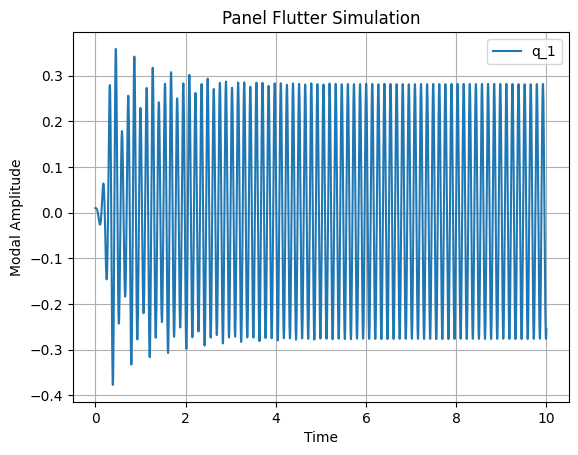

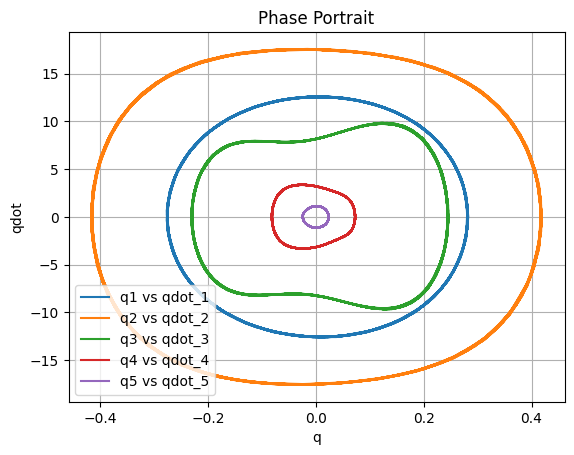

Running simulation for parameter set 2 with zeta_1 = 1.0


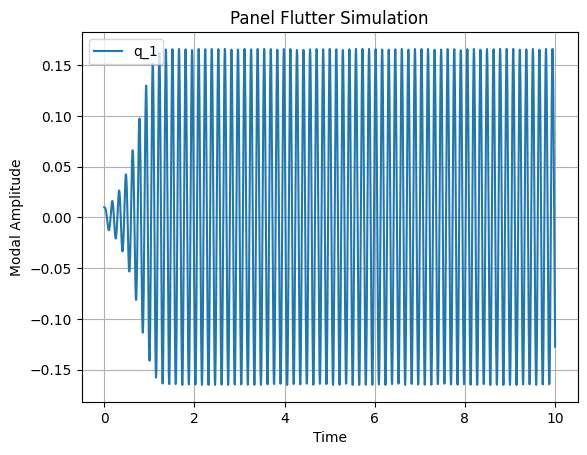

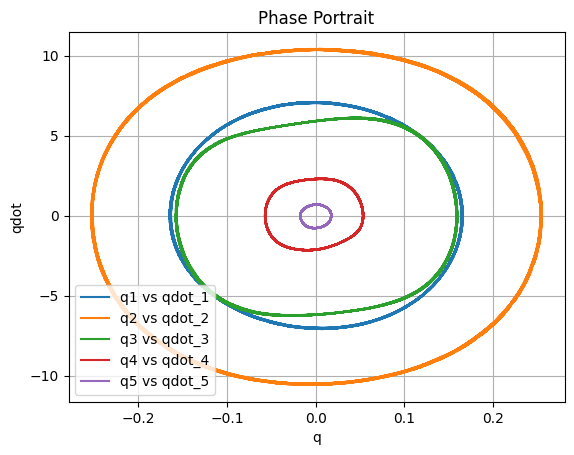

In [60]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params1 = setup_parameters(lam=500, N=6,zeta_1=0.1, M_inf=25)
params2 = setup_parameters(lam=500, N=6,zeta_1=1.0, M_inf=25)

params = [params1, params2]
for i, param in enumerate(params):
    print(f"Running simulation for parameter set {i+1} with zeta_1 = {param['zeta_1']}")    
    y0 = np.zeros(2*param['N']) # Initial conditions (q_n and qdot_n)
    y0[0] = 0.01 # Initial condition for q_1

    sol = solve_ivp(flutter_model, [0,10], y0, args=(param,))
    plt.plot(sol.t, sol.y[0,:], label='q_1')
    # plt.plot(sol.t, sol.y[1,:], label='q_2')
    # plt.plot(sol.t, sol.y[2,:], label='q_3')
    # plt.plot(sol.t, sol.y[3,:], label='q_4')
    # plt.plot(sol.t, sol.y[4,:], label='q_5')
    plt.xlabel('Time')
    plt.ylabel('Modal Amplitude')
    plt.title('Panel Flutter Simulation')
    plt.legend()
    plt.grid()
    plt.show()

    # Phase Portrait
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(sol.y[0,len(sol.t)//2:], sol.y[param['N'],len(sol.t)//2:], label='q1 vs qdot_1')
    ax.plot(sol.y[1,len(sol.t)//2:], sol.y[param['N']+1,len(sol.t)//2:], label='q2 vs qdot_2')
    ax.plot(sol.y[2,len(sol.t)//2:], sol.y[param['N']+2,len(sol.t)//2:], label='q3 vs qdot_3')
    ax.plot(sol.y[3,len(sol.t)//2:], sol.y[param['N']+3,len(sol.t)//2:], label='q4 vs qdot_4')
    ax.plot(sol.y[4,len(sol.t)//2:], sol.y[param['N']+4,len(sol.t)//2:], label='q5 vs qdot_5')   
    ax.set_xlabel('q')
    ax.set_ylabel('qdot')
    ax.set_title('Phase Portrait')
    ax.legend()
    ax.grid()
    plt.show()